# Dataset Exploration: Human Movement

This notebook explores the experimental movement dataset collected for the
Adaptive Embodied AI project.

The dataset contains upper-body movement recordings from multiple participants
and sessions, extracted from webcam-based pose estimation.

The purpose of this analysis is to:

1. verify the structure and quality of the experimental data;
2. understand the distribution of movement classes;
3. examine how movement features vary across participants and sessions;
4. investigate whether participant-specific differences are present;
5. identify potential issues before model training.

These observations will inform the subsequent experiment comparing:

- a generic movement model trained across participants; and
- a personalised model adapted to an individual participant.

This notebook is exploratory. It does not perform model training or claim
generalisation beyond the collected dataset.

## Experimental Design

The dataset follows a participant/session/trial hierarchy:

- **Participant** — individual performing the movements
- **Session** — separate recording session for a participant
- **Trial** — one execution of a movement
- **Movement class** — the instructed movement

The current experiment contains:

- 2 participants
- 2 sessions per participant
- 25 trials per session
- 5 movement classes
- 5 repetitions of each movement per session

Movement classes:

- `neutral`
- `raise_arms`
- `lean_left`
- `lean_right`
- `lean_forward`

The recordings were collected using webcam-based pose estimation and converted
into compact movement features.

In [1]:
# Imports and plotting configuration

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("../data/movement")

## Load the Experimental Dataset

Each participant/session recording is stored as a separate CSV file.

For this analysis we use:

- `P01_session_01.csv`
- `P01_session_02.csv`
- `P02_session_01.csv`
- `P02_session_02.csv`

The files are combined into a single dataframe while preserving participant
and session identifiers.

In [2]:
# Load participant/session recordings

files = sorted(DATA_DIR.glob("P*_session_*.csv"))

if not files:
    raise FileNotFoundError(
        f"No participant/session CSV files found in {DATA_DIR.resolve()}"
    )

print(f"Found {len(files)} files:")
for file in files:
    print(f"  - {file.name}")

frames = []

for file in files:
    frame = pd.read_csv(file)
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)

print()
print(f"Combined dataset shape: {df.shape}")

display(df.head())

Found 4 files:
  - P01_session_01.csv
  - P01_session_02.csv
  - P02_session_01.csv
  - P02_session_02.csv

Combined dataset shape: (12049, 14)


,participant_id,session_id,trial_id,movement_label,timestamp,shoulder_width,head_offset_x,head_offset_y,torso_dx,torso_dy,movement_speed,head_offset_z,torso_dz,movement_speed_3d
0,P01,session_01,1,neutral,0.000286,0.512240,-0.003828,-0.809468,0.000000,0.000000,0.000000,-1.819797,0.000000,0.000000
1,P01,session_01,1,neutral,0.089765,0.522485,0.001988,-0.821021,0.001142,0.041825,0.467600,-1.964989,-0.080764,1.016539
2,P01,session_01,1,neutral,0.120218,0.526950,-0.002607,-0.825294,0.004594,0.006284,0.255614,-1.953916,-0.004368,0.293103
3,P01,session_01,1,neutral,0.161072,0.528400,-0.000946,-0.826692,0.001198,0.004504,0.114079,-1.970659,-0.041060,1.011501
4,P01,session_01,1,neutral,0.199235,0.528685,-0.000832,-0.819518,-0.000120,0.001390,0.036564,-2.000928,-0.021275,0.558671


## Dataset Overview

We first inspect the dimensions, columns and data types before analysing the
movement patterns.

In [3]:
# Dataset dimensions and schema

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
for column in df.columns:
    print(f"  - {column}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Rows: 12049
Columns: 14

Columns:
  - participant_id
  - session_id
  - trial_id
  - movement_label
  - timestamp
  - shoulder_width
  - head_offset_x
  - head_offset_y
  - torso_dx
  - torso_dy
  - movement_speed
  - head_offset_z
  - torso_dz
  - movement_speed_3d

Data types:


,dtype
participant_id,str
session_id,str
trial_id,int64
movement_label,str
timestamp,float64
shoulder_width,float64
head_offset_x,float64
head_offset_y,float64
torso_dx,float64
torso_dy,float64


In [4]:
# Dataset identifiers and movement classes

print("Participants:")
print(sorted(df["participant_id"].unique()))

print("\nSessions:")
display(
    df[["participant_id", "session_id"]]
    .drop_duplicates()
    .sort_values(["participant_id", "session_id"])
    .reset_index(drop=True)
)

print("\nMovement classes:")
print(sorted(df["movement_label"].unique()))

Participants:
['P01', 'P02']

Sessions:


,participant_id,session_id
0,P01,session_01
1,P01,session_02
2,P02,session_01
3,P02,session_02



Movement classes:
['lean_forward', 'lean_left', 'lean_right', 'neutral', 'raise_arms']


## Trial Structure

The learning problem is ultimately trial-based rather than frame-based.

Each trial contains a short temporal sequence of pose-derived features.
Therefore, we inspect the number of observations per trial and verify that the experimental design is balanced.

In [5]:
# Trials per participant and session

trial_summary = (
    df.groupby(
        ["participant_id", "session_id"],
        as_index=False
    )
    .agg(
        trials=("trial_id", "nunique"),
        movements=("movement_label", "nunique"),
        observations=("trial_id", "size")
    )
)

display(trial_summary)

,participant_id,session_id,trials,movements,observations
0,P01,session_01,25,5,3013
1,P01,session_02,25,5,3011
2,P02,session_01,25,5,3012
3,P02,session_02,25,5,3013


movement_label
lean_forward    20
lean_left       20
lean_right      20
neutral         20
raise_arms      20
Name: count, dtype: int64

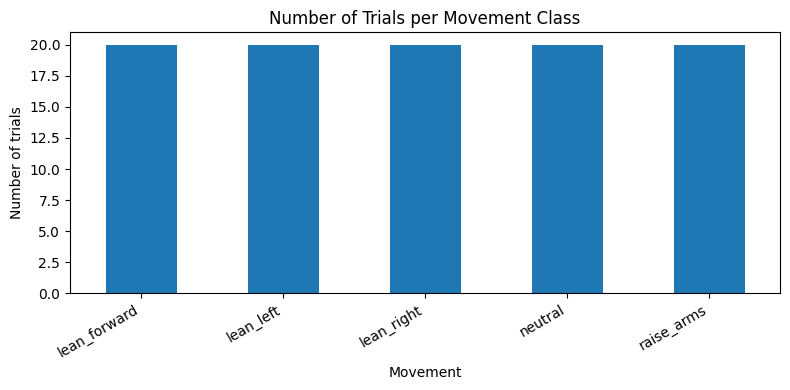

In [6]:
# Movement distribution

movement_counts = (
    df[["participant_id", "session_id", "trial_id", "movement_label"]]
    .drop_duplicates()
    ["movement_label"]
    .value_counts()
    .sort_index()
)

display(movement_counts)

ax = movement_counts.plot(
    kind="bar",
    figsize=(8, 4),
    title="Number of Trials per Movement Class"
)

ax.set_xlabel("Movement")
ax.set_ylabel("Number of trials")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Temporal Structure

The model will operate on movement sequences rather than isolated frames.

Before modelling, we therefore examine:

- number of observations per trial;
- trial duration;
- sampling interval.

Small differences in sequence length are expected because webcam acquisition
is not perfectly fixed-rate.

In [7]:
# Trial lengths and durations

trial_stats = (
    df.groupby(
        ["participant_id", "session_id", "trial_id", "movement_label"]
    )
    .agg(
        observations=("timestamp", "size"),
        duration=("timestamp", lambda x: x.max() - x.min())
    )
    .reset_index()
)

display(trial_stats.describe())

print("\nTrial length range:")
print(
    f"Minimum: {trial_stats['observations'].min()} observations"
)
print(
    f"Maximum: {trial_stats['observations'].max()} observations"
)

print("\nTrial duration range:")
print(
    f"Minimum: {trial_stats['duration'].min():.3f} s"
)
print(
    f"Maximum: {trial_stats['duration'].max():.3f} s"
)

,trial_id,observations,duration
count,100.000000,100.000000,100.000000
mean,13.000000,120.490000,3.978980
std,7.247431,0.771919,0.010930
min,1.000000,117.000000,3.951716
25%,7.000000,120.000000,3.968287
50%,13.000000,121.000000,3.983726
75%,19.000000,121.000000,3.984197
max,25.000000,121.000000,3.999787



Trial length range:
Minimum: 117 observations
Maximum: 121 observations

Trial duration range:
Minimum: 3.952 s
Maximum: 4.000 s


## Feature Distributions

The current representation combines:

### 2D features
- shoulder width
- head offset in x/y
- torso displacement in x/y
- 2D movement speed

### Depth-related features
- head offset in z
- torso displacement in z
- 3D movement speed

These features are derived from the pose representation and provide a compact
description of upper-body movement.

The distributions are inspected before deciding whether additional
normalisation or robust preprocessing is required.

In [8]:
# Numerical feature summary

feature_columns = [
    "shoulder_width",
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "movement_speed",
    "head_offset_z",
    "torso_dz",
    "movement_speed_3d",
]

feature_summary = df[feature_columns].describe().T

display(
    feature_summary[
        ["mean", "std", "min", "25%", "50%", "75%", "max"]
    ].round(4)
)

,mean,std,min,25%,50%,75%,max
shoulder_width,0.5287,0.0767,0.3107,0.4946,0.5262,0.5797,0.6991
head_offset_x,0.0223,0.1277,-0.3399,-0.0141,0.0285,0.0711,0.3464
head_offset_y,-0.7924,0.0553,-0.9886,-0.8371,-0.7941,-0.7577,-0.6015
torso_dx,0.0001,0.0050,-0.0811,-0.0010,-0.0000,0.0009,0.0564
torso_dy,-0.0003,0.0065,-0.1334,-0.0012,-0.0000,0.0010,0.1253
movement_speed,0.1317,0.2100,0.0000,0.0262,0.0627,0.1468,4.1384
head_offset_z,-1.8499,0.1350,-2.5817,-1.9379,-1.8649,-1.7527,-1.4495
torso_dz,0.0002,0.0907,-1.0912,-0.0285,-0.0002,0.0273,0.8017
movement_speed_3d,1.6312,2.2370,0.0000,0.3511,0.8690,1.9766,33.8756


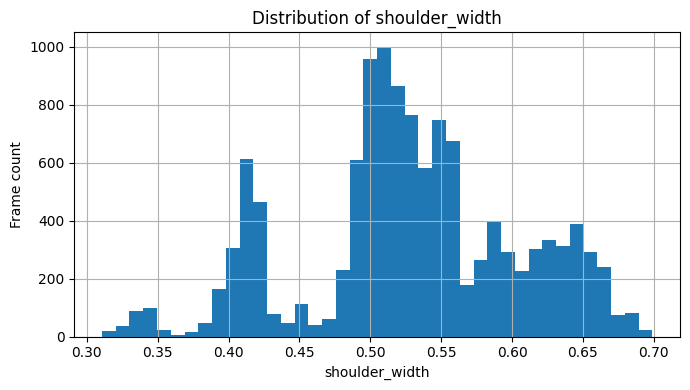

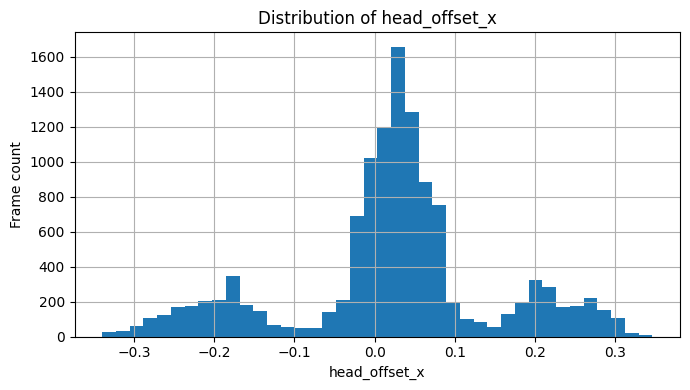

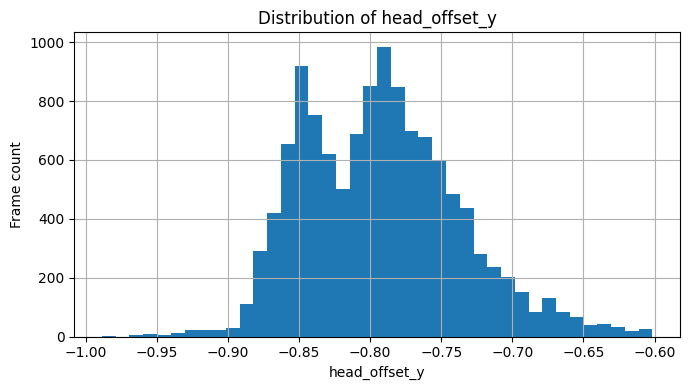

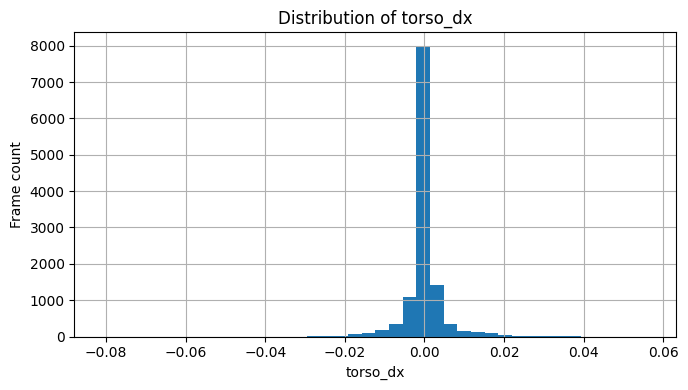

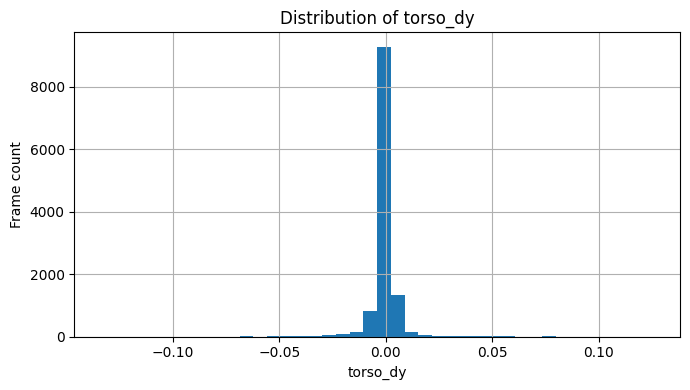

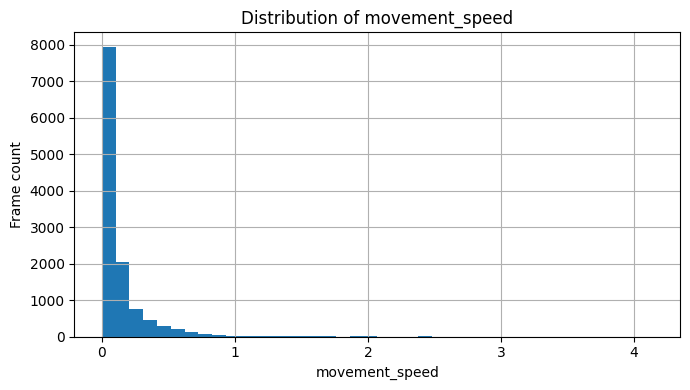

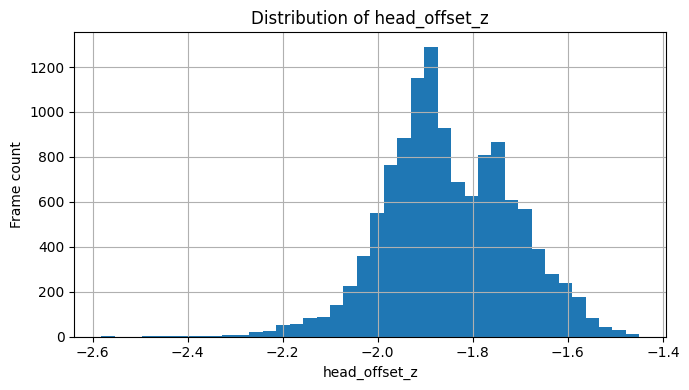

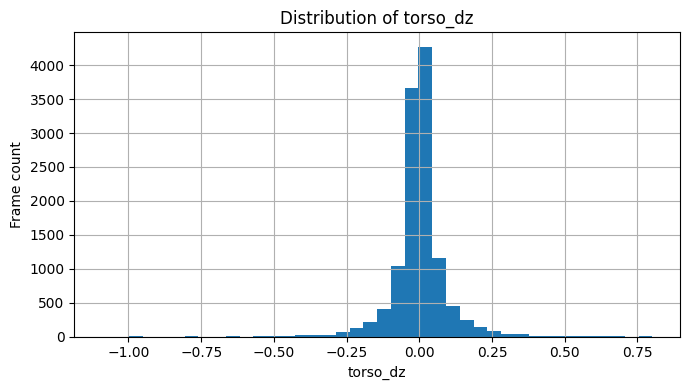

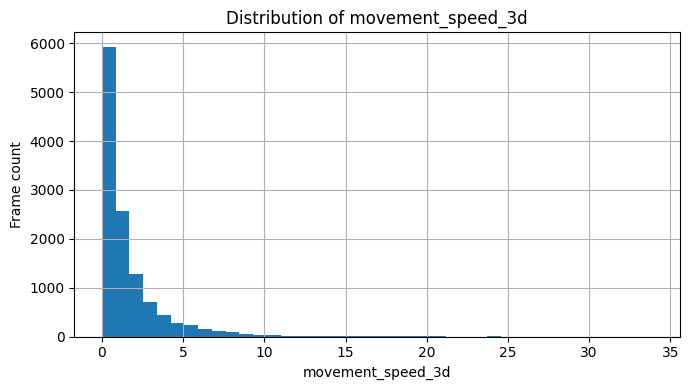

In [9]:
# Feature distributions

for feature in feature_columns:
    plt.figure(figsize=(7, 4))
    
    df[feature].hist(bins=40)
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frame count")
    plt.tight_layout()
    plt.show()

## Movement-Specific Feature Differences

A useful first question is whether the engineered features contain information that distinguishes the instructed movement classes.

We therefore compare the distributions of selected features across movements.

This is descriptive analysis only. Clear separation here does not imply that a classifier will generalise to unseen participants.

<Figure size 800x400 with 0 Axes>

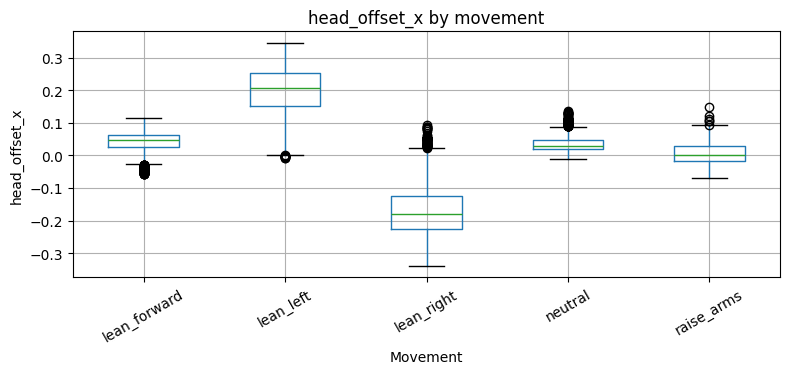

<Figure size 800x400 with 0 Axes>

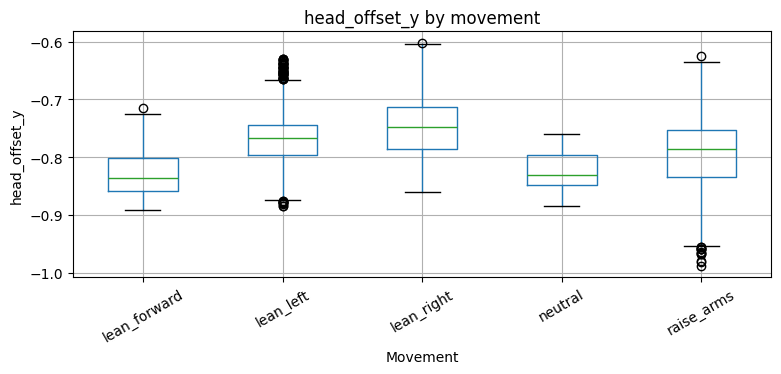

<Figure size 800x400 with 0 Axes>

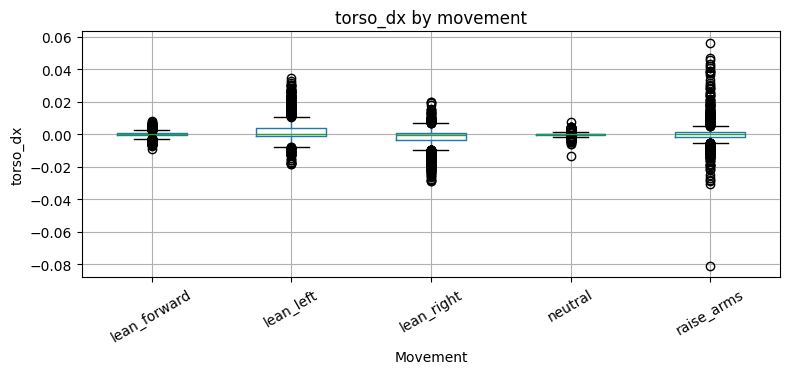

<Figure size 800x400 with 0 Axes>

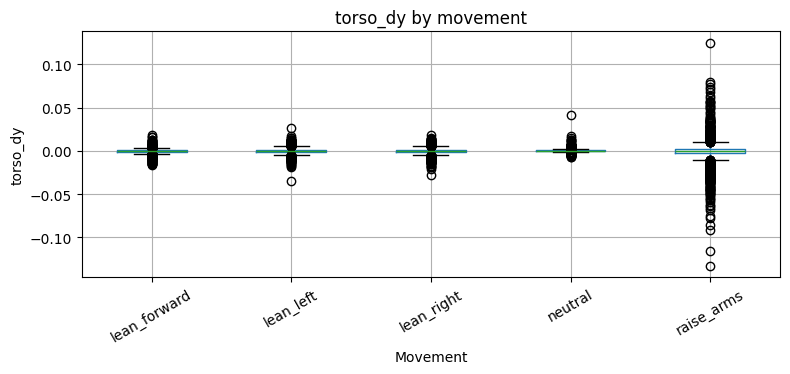

<Figure size 800x400 with 0 Axes>

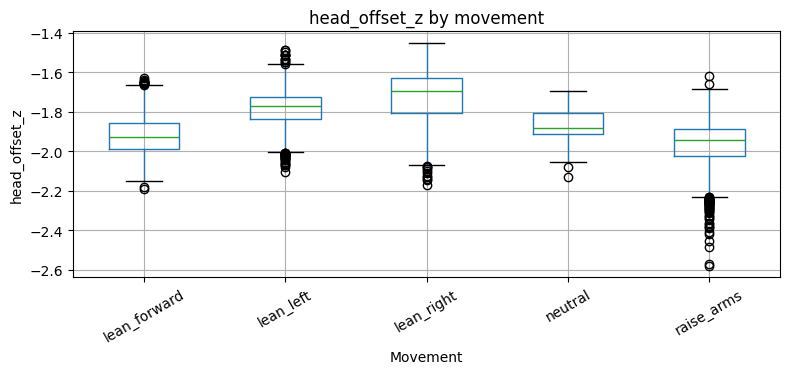

<Figure size 800x400 with 0 Axes>

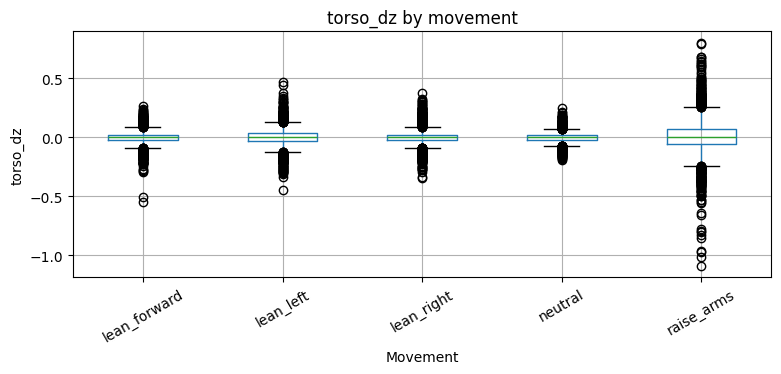

<Figure size 800x400 with 0 Axes>

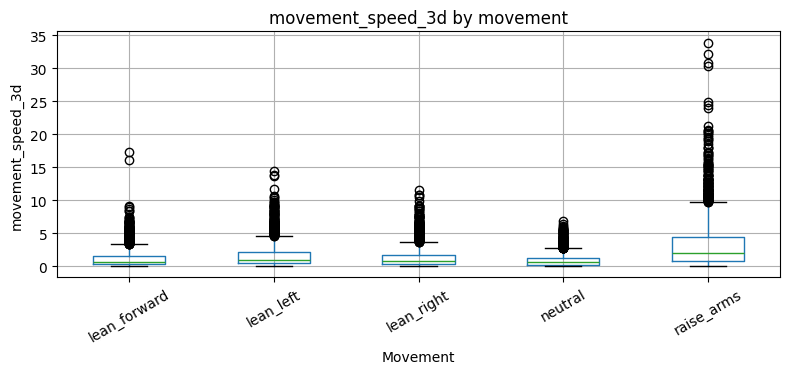

In [10]:
# Selected features by movement

selected_features = [
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "head_offset_z",
    "torso_dz",
    "movement_speed_3d",
]

for feature in selected_features:
    plt.figure(figsize=(8, 4))
    
    df.boxplot(
        column=feature,
        by="movement_label",
        figsize=(8, 4)
    )
    
    plt.title(f"{feature} by movement")
    plt.suptitle("")
    plt.xlabel("Movement")
    plt.ylabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Participant-Specific Differences

Personalisation is only meaningful if participants exhibit measurable
differences in their movement patterns.

We therefore compare feature distributions across participants.

The goal is not to prove that the participants are fundamentally different, but to investigate whether the same movement classes are expressed with
participant-specific characteristics.

These differences motivate the later comparison between a generic model and a personalised/adapted model.

In [11]:
# Feature means by participant and movement

participant_feature_means = (
    df.groupby(
        ["participant_id", "movement_label"]
    )[selected_features]
    .mean()
    .round(4)
)

display(participant_feature_means)

head_offset_x  head_offset_y  torso_dx  torso_dy  head_offset_z  torso_dz  \
participant_id movement_label                                                                              
P01            lean_forward           0.0387        -0.8459   -0.0000   -0.0004        -1.9821   -0.0065   
               lean_left              0.2072        -0.7775    0.0025   -0.0000        -1.8182   -0.0001   
               lean_right            -0.1806        -0.7302   -0.0022   -0.0004        -1.7433   -0.0006   
               neutral                0.0422        -0.8289   -0.0001    0.0001        -1.9117    0.0005   
               raise_arms             0.0184        -0.8091    0.0003   -0.0011        -2.0130    0.0025   
P02            lean_forward           0.0449        -0.8145   -0.0000   -0.0004        -1.8421   -0.0009   
               lean_left              0.1770        -0.7618    0.0024   -0.0000        -1.7536    0.0004   
               lean_right            -0.1500        -0.7601   -0.0019   -0.0001        -1.6974    0.0004   
               neutral                0.0303        -0.8176    0.0000    0.0000        -1.8188   -0.0003   
               raise_arms            -0.0055        -0.7784    0.0000   -0.0012        -1.9193    0.0064   

                               movement_speed_3d  
participant_id movement_label                     
P01            lean_forward               1.1163  
               lean_left                  2.0370  
               lean_right                 1.6386  
               neutral                    1.0984  
               raise_arms                 4.0174  
P02            lean_forward               1.2220  
               lean_left                  1.1718  
               lean_right                 0.9375  
               neutral                    0.6603  
               raise_arms                 2.4099

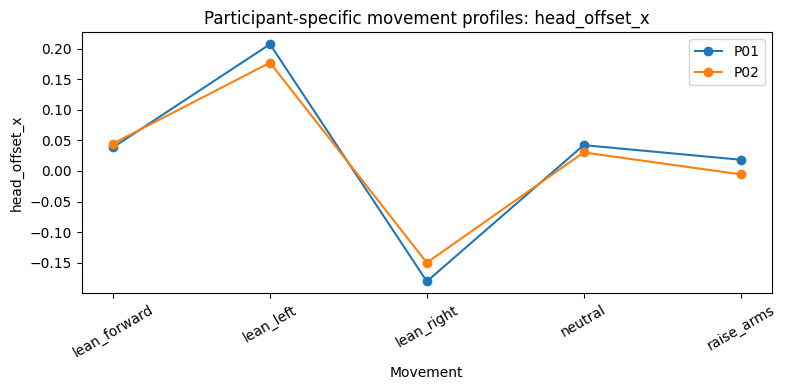

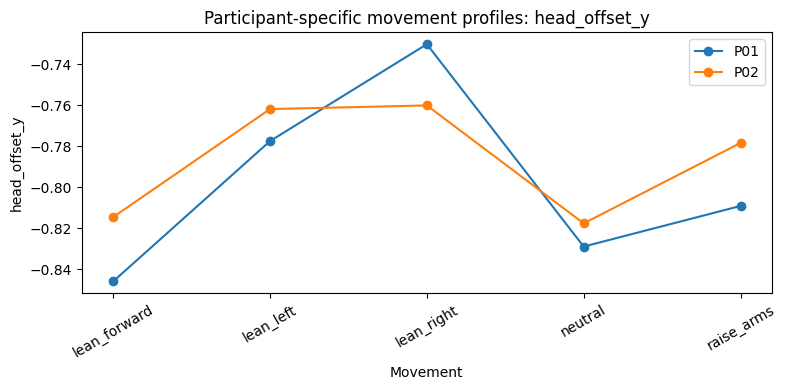

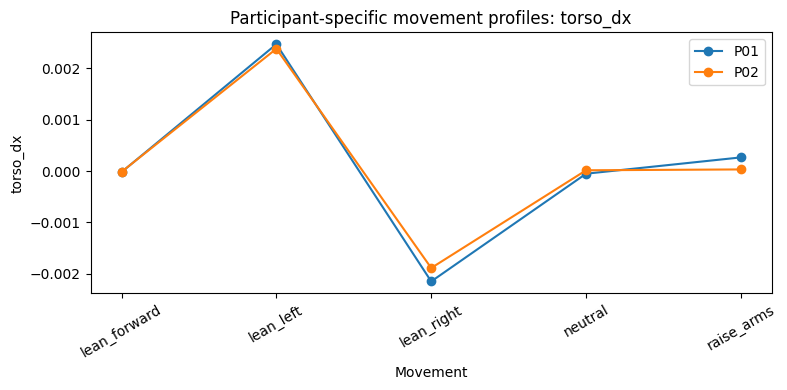

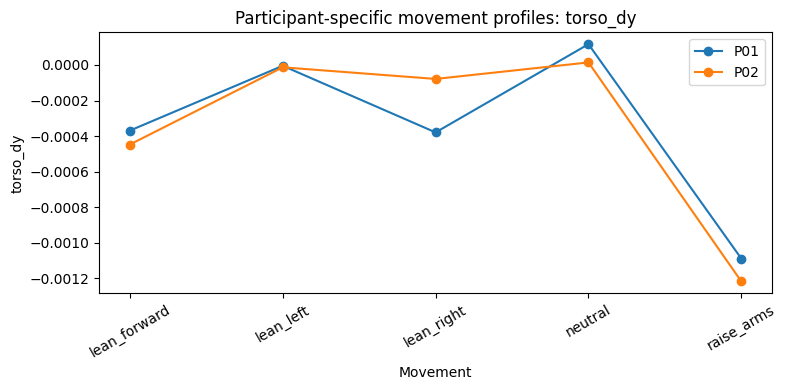

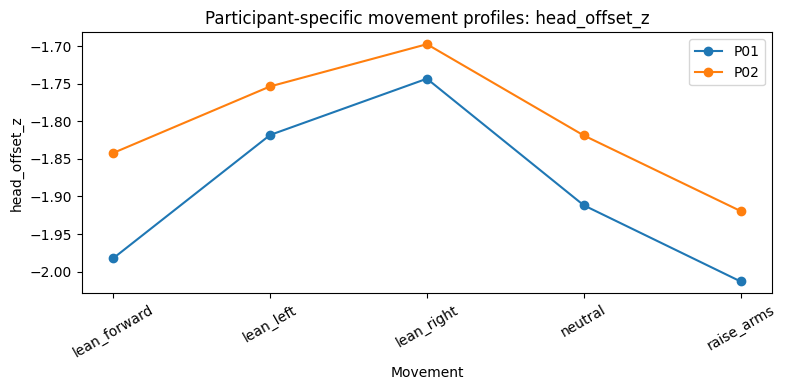

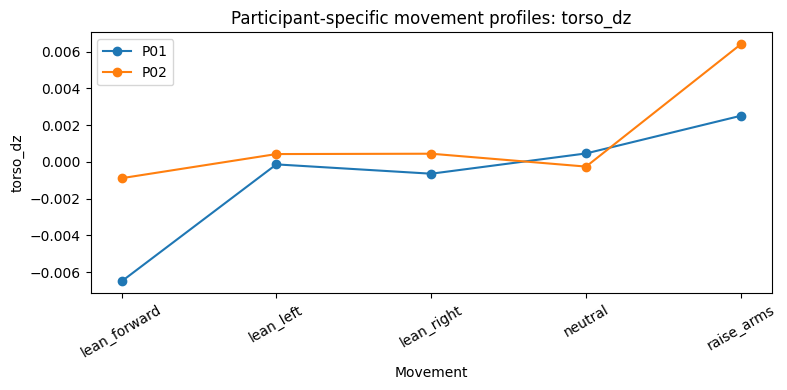

In [12]:
# Participant comparison for selected features

for feature in [
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "head_offset_z",
    "torso_dz",
]:
    plt.figure(figsize=(8, 4))
    
    for participant in sorted(df["participant_id"].unique()):
        subset = df[df["participant_id"] == participant]
        
        movement_means = (
            subset.groupby("movement_label")[feature]
            .mean()
            .reindex(sorted(df["movement_label"].unique()))
        )
        
        plt.plot(
            movement_means.index,
            movement_means.values,
            marker="o",
            label=participant
        )
    
    plt.title(f"Participant-specific movement profiles: {feature}")
    plt.xlabel("Movement")
    plt.ylabel(feature)
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Session-to-Session Consistency

The experiment will eventually use multiple sessions per participant.

We therefore need to distinguish:

- variation between participants; from
- ordinary variation between sessions of the same participant.

This comparison is particularly relevant for personalisation: an adaptation method should ideally learn participant-specific characteristics without simply memorising one recording session.

In [13]:
# Compare sessions within participants

session_means = (
    df.groupby(
        ["participant_id", "session_id", "movement_label"]
    )[selected_features]
    .mean()
    .reset_index()
)

display(session_means.head(20))

,participant_id,session_id,movement_label,head_offset_x,head_offset_y,torso_dx,torso_dy,head_offset_z,torso_dz,movement_speed_3d
0,P01,session_01,lean_forward,0.014051,-0.838887,-0.000044,-0.000502,-1.960633,-0.007310,1.330039
1,P01,session_01,lean_left,0.206556,-0.763963,0.002595,0.000190,-1.829584,-0.001646,1.858456
2,P01,session_01,lean_right,-0.144426,-0.729269,-0.001783,-0.000341,-1.753214,-0.000459,1.555561
3,P01,session_01,neutral,0.055535,-0.809416,-0.000030,0.000177,-1.933758,-0.000049,1.128763
4,P01,session_01,raise_arms,0.043852,-0.750430,0.000240,-0.001018,-1.969059,0.002338,4.078024
5,P01,session_02,lean_forward,0.063355,-0.852908,0.000002,-0.000237,-2.003590,-0.005698,0.902464
6,P01,session_02,lean_left,0.207893,-0.791015,0.002349,-0.000200,-1.806740,0.001376,2.216216
7,P01,session_02,lean_right,-0.216593,-0.731117,-0.002518,-0.000418,-1.733478,-0.000829,1.721410
8,P01,session_02,neutral,0.028860,-0.848510,-0.000074,0.000057,-1.889425,0.000969,1.067893
9,P01,session_02,raise_arms,-0.007016,-0.867554,0.000292,-0.001160,-2.056745,0.002677,3.956901


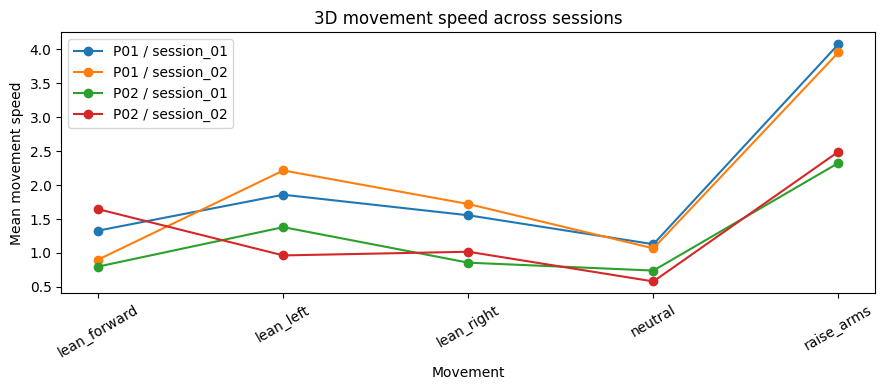

In [14]:
# Session comparison for movement speed

feature = "movement_speed_3d"

plt.figure(figsize=(9, 4))

for (participant, session), group in session_means.groupby(
    ["participant_id", "session_id"]
):
    movement_means = (
        group.set_index("movement_label")[feature]
        .reindex(sorted(df["movement_label"].unique()))
    )
    
    plt.plot(
        movement_means.index,
        movement_means.values,
        marker="o",
        label=f"{participant} / {session}"
    )

plt.title("3D movement speed across sessions")
plt.xlabel("Movement")
plt.ylabel("Mean movement speed")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

## Feature Relationships

The current feature representation is intentionally compact.

Before modelling, we inspect correlations between features to identify
strongly redundant measurements and understand the structure of the
representation.

Correlation does not imply that a feature should automatically be removed, the analysis is used to inform later modelling decisions.

In [15]:
# Feature correlation matrix

correlation = df[feature_columns].corr()

display(correlation.round(2))

,shoulder_width,head_offset_x,head_offset_y,torso_dx,torso_dy,movement_speed,head_offset_z,torso_dz,movement_speed_3d
shoulder_width,1.00,0.01,-0.24,-0.02,0.04,-0.33,0.24,-0.01,-0.37
head_offset_x,0.01,1.00,-0.22,0.19,0.02,-0.02,-0.19,-0.00,0.01
head_offset_y,-0.24,-0.22,1.00,-0.04,-0.05,0.01,0.59,0.02,0.06
torso_dx,-0.02,0.19,-0.04,1.00,0.05,0.12,-0.04,-0.01,-0.01
torso_dy,0.04,0.02,-0.05,0.05,1.00,-0.20,-0.02,-0.19,-0.01
movement_speed,-0.33,-0.02,0.01,0.12,-0.20,1.00,-0.15,-0.02,0.33
head_offset_z,0.24,-0.19,0.59,-0.04,-0.02,-0.15,1.00,0.05,-0.19
torso_dz,-0.01,-0.00,0.02,-0.01,-0.19,-0.02,0.05,1.00,-0.00
movement_speed_3d,-0.37,0.01,0.06,-0.01,-0.01,0.33,-0.19,-0.00,1.00


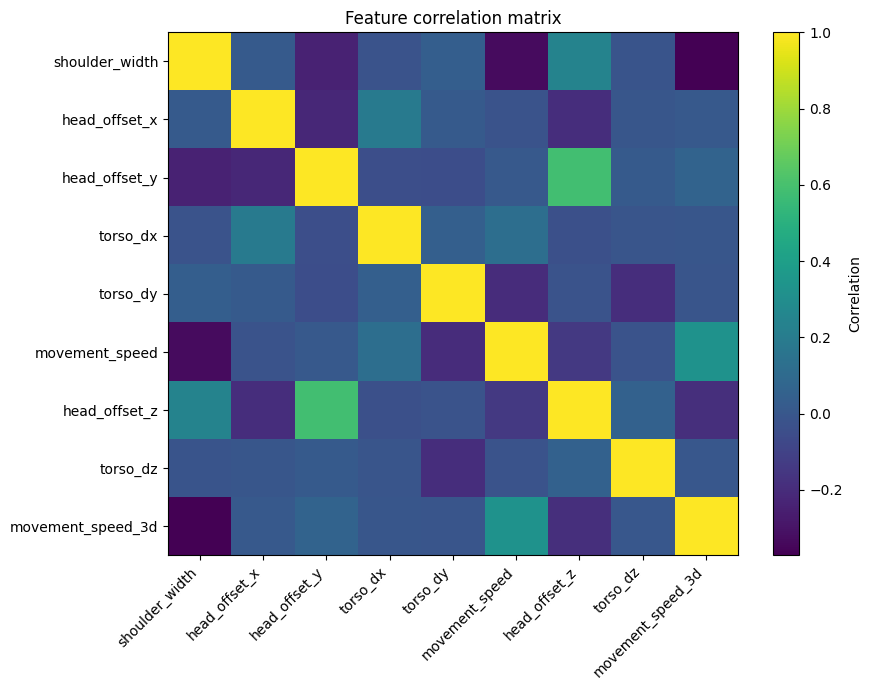

In [16]:
# Visualise feature correlations

plt.figure(figsize=(9, 7))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.colorbar(label="Correlation")
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## Temporal Movement Profiles

The dataset contains sequential observations rather than independent samples.

To verify that the features capture temporal movement, we inspect a small number of representative trials.

The purpose is qualitative: to understand how the extracted features evolve during an individual movement.

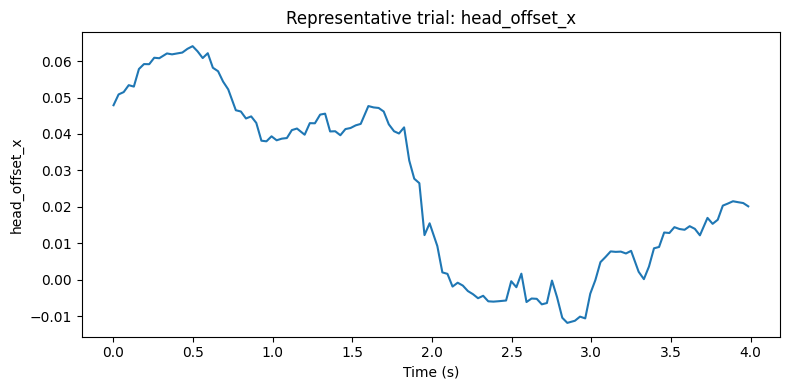

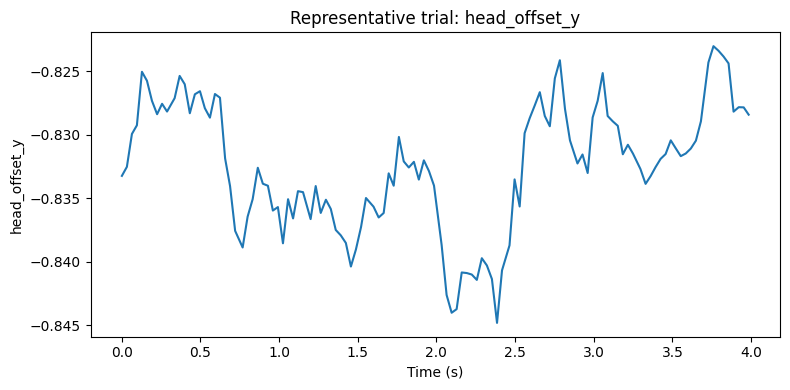

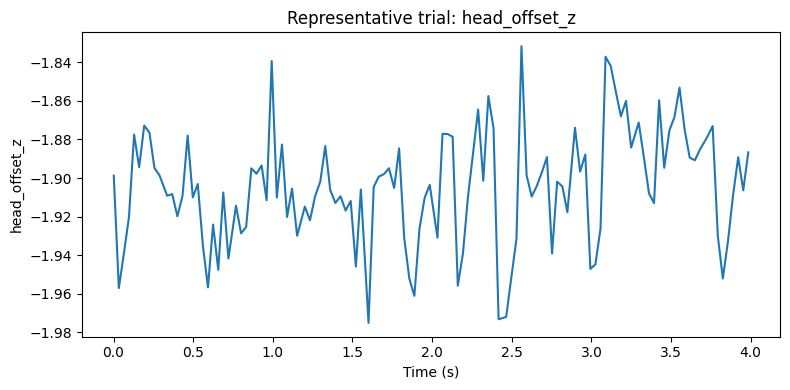

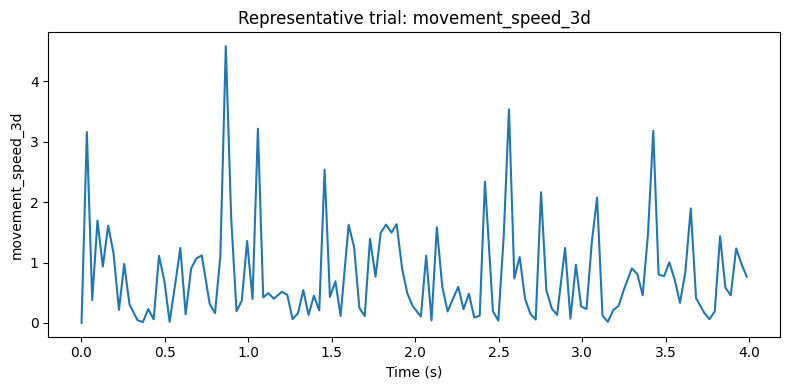

In [17]:
# Plot a representative trial

example = (
    df[
        (df["participant_id"] == "P01")
        & (df["session_id"] == "session_01")
        & (df["trial_id"] == 2)
    ]
    .copy()
)

if example.empty:
    raise ValueError("Representative trial was not found.")

for feature in [
    "head_offset_x",
    "head_offset_y",
    "head_offset_z",
    "movement_speed_3d",
]:
    plt.figure(figsize=(8, 4))
    
    plt.plot(
        example["timestamp"],
        example[feature]
    )
    
    plt.title(f"Representative trial: {feature}")
    plt.xlabel("Time (s)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()